# 03 - E: Eksplorasi Data
**Kelompok 12 - Pariwisata Daerah Jawa Barat**

Eksplorasi dua dataset utama:
1. **Wisata Alam** - Kunjungan wisatawan ke kawasan wisata alam Jawa Barat (2016-2022)
2. **Hotel TPK** - Tingkat Penghunian Kamar hotel di Jawa Barat (2019-2025)

Bertujuan untuk memahami pola, tren, dampak COVID-19, dan hubungan lintas dataset.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
BG_COLOR      = '#0d1117'
PRIMARY_COLOR = '#00B4D8'
ACCENT_COLOR  = '#FF6B35'
GREEN_COLOR   = '#2ECC71'
DPI           = 150
OUTPUT_DIR    = '../outputs/figures/'

BULAN_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                'Jul', 'Agt', 'Sep', 'Okt', 'Nov', 'Des']

---
## Dataset yang Digunakan

**1. Wisata Alam** *(dataset utama)* — `data/clean/dishut_clean_v2.csv`
Jumlah pengunjung (wisnus + wisman) per kawasan wisata alam | 296 kawasan | 2016–2022

**2. Hotel TPK** *(dataset pendukung)* — `data/preprocessed/hotel_scrubbed.csv`
Tingkat Penghunian Kamar (TPK) hotel per bulan | 3 jenis hotel | Jan 2019–Des 2025


In [12]:
dishut = pd.read_csv('../data/clean/dishut_clean_v2.csv')
hotel  = pd.read_csv('../data/preprocessed/hotel_scrubbed.csv', parse_dates=['periode'])
hotel['is_covid'] = hotel['is_covid'].astype(str).str.lower() == 'true'

print(f'Wisata Alam : {dishut.shape[0]} baris x {dishut.shape[1]} kolom')
print(f'Hotel       : {hotel.shape[0]} baris x {hotel.shape[1]} kolom')

Wisata Alam : 2652 baris x 10 kolom
Hotel       : 252 baris x 7 kolom


---
## 1. Eksplorasi Wisata Alam

### Statistik Deskriptif

In [13]:
print('=' * 55)
print('Wisata Alam - Statistik Deskriptif')
print('=' * 55)

print(f'\nJumlah kawasan unik   : {dishut["pengelola_kawasan"].nunique()}')
print(f'Tipe pengelola        : {dishut["tipe_pengelola"].unique().tolist()}')
print(f'Rentang tahun         : {dishut["tahun"].min()} - {dishut["tahun"].max()}')

yearly_total = dishut.groupby('tahun')['jumlah_wisatawan'].sum()
print(f'\n--- Total Pengunjung per Tahun ---')
print(yearly_total.to_string())

flag_summary = (dishut.drop_duplicates(subset=['tahun', 'data_flag'])
                      [['tahun', 'data_flag']]
                      .sort_values('tahun'))
print(f'\n--- Kualitas Data per Tahun ---')
print(flag_summary.to_string(index=False))

Wisata Alam - Statistik Deskriptif

Jumlah kawasan unik   : 296
Tipe pengelola        : ['LAINNYA', 'BKSDA', 'TN', 'TAHURA', 'PERHUTANI', 'KPH', 'TWA']
Rentang tahun         : 2016 - 2022

--- Total Pengunjung per Tahun ---
tahun
2016    4227232
2017      84999
2018     195056
2019      97061
2020      97061
2021          0
2022     440785

--- Kualitas Data per Tahun ---
 tahun       data_flag
  2016          NORMAL
  2017          NORMAL
  2018          NORMAL
  2019          NORMAL
  2020    SUSPECT_COPY
  2021          NORMAL
  2022 INCOMPLETE_YEAR


### Viz 1 — Tren Total Pengunjung (2016–2022)

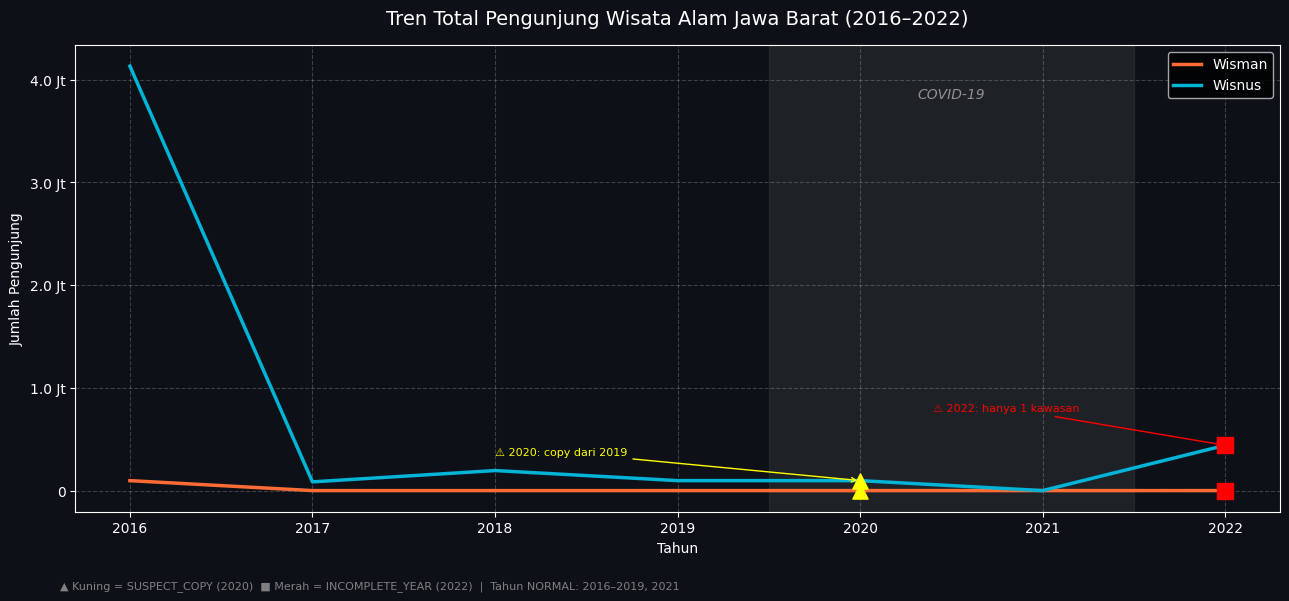

Saved: wisataalam_viz1_tren_pengunjung.png


In [14]:
from matplotlib.ticker import FuncFormatter

def _fmt(x, pos):
    return f'{x/1e6:.1f} Jt' if x >= 1e6 else (f'{x/1e3:.0f} Rb' if x >= 1e3 else str(int(x)))

trend_data = dishut.groupby(['tahun', 'jenis_wisatawan'])['jumlah_wisatawan'].sum().unstack()

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt))

JENIS_COLOR = {'WISATAWAN NUSANTARA': PRIMARY_COLOR, 'WISATAWAN MANCANEGARA': ACCENT_COLOR}
JENIS_LABEL = {'WISATAWAN NUSANTARA': 'Wisnus', 'WISATAWAN MANCANEGARA': 'Wisman'}

for col in trend_data.columns:
    ax.plot(trend_data.index, trend_data[col],
            label=JENIS_LABEL[col], color=JENIS_COLOR[col], linewidth=2.5, zorder=2)
    ax.scatter(2020, trend_data.loc[2020, col], color='yellow', marker='^', s=120, zorder=5)
    ax.scatter(2022, trend_data.loc[2022, col], color='red',    marker='s', s=120, zorder=5)

ax.axvspan(2019.5, 2021.5, color='gray', alpha=0.15)
ax.text(2020.5, ax.get_ylim()[1] * 0.88, 'COVID-19',
        color='white', ha='center', alpha=0.5, fontstyle='italic')

max_val = float(trend_data.max().max())
ax.annotate('⚠ 2020: copy dari 2019',
            xy=(2020, float(trend_data.loc[2020].max())),
            xytext=(2018, float(trend_data.loc[2020].max()) + max_val * 0.06),
            arrowprops=dict(arrowstyle='->', color='yellow'), color='yellow', fontsize=8)
ax.annotate('⚠ 2022: hanya 1 kawasan',
            xy=(2022, float(trend_data.loc[2022].max())),
            xytext=(2020.4, float(trend_data.loc[2022].max()) + max_val * 0.08),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=8)

ax.set_title('Tren Total Pengunjung Wisata Alam Jawa Barat (2016–2022)', fontsize=14, pad=15)
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Pengunjung')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.2)
plt.figtext(0.05, 0.01,
            '▲ Kuning = SUSPECT_COPY (2020)  ■ Merah = INCOMPLETE_YEAR (2022)  |  Tahun NORMAL: 2016–2019, 2021',
            color='gray', fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}wisataalam_viz1_tren_pengunjung.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: wisataalam_viz1_tren_pengunjung.png')

**Interpretasi Viz 1:**
- Wisnus mendominasi kunjungan secara absolut; Wisman hanya sebagian kecil — membenarkan penggunaan `rasio_wisman` sebagai fitur diferensiasi, bukan volume absolut.
- Lonjakan 2016 kemungkinan data historis awal yang tidak konsisten dengan tahun berikutnya.
- Data 2020 (SUSPECT_COPY) dan 2022 (INCOMPLETE_YEAR) dikecualikan dari modeling — hanya **5 tahun NORMAL** yang dipakai.

### Viz 2 — Peta Kawasan: Volume vs Konsistensi Pelaporan (Preview Segmentasi)

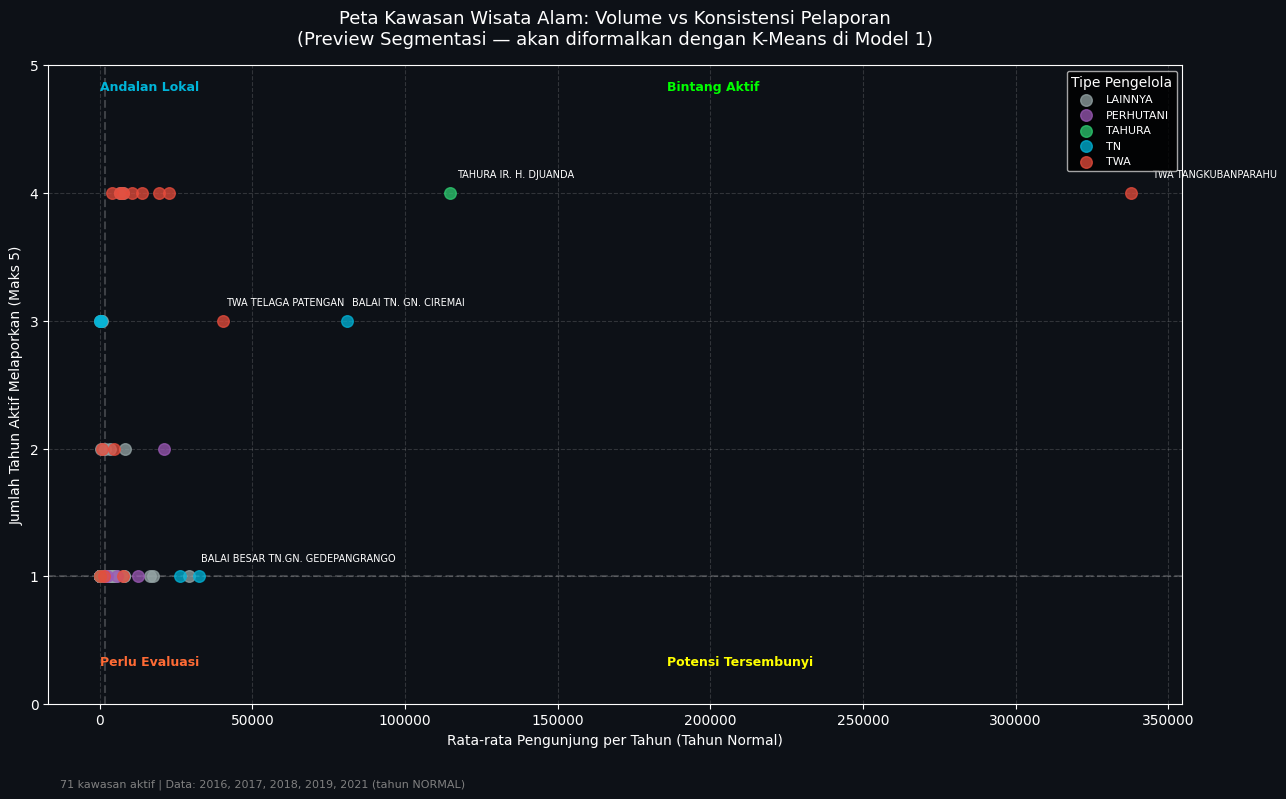

Saved: wisataalam_viz2_preview_segmentasi.png


In [15]:
NORMAL_YEARS = [2016, 2017, 2018, 2019, 2021]
df_n = dishut[dishut['tahun'].isin(NORMAL_YEARS)].copy()

yearly_n  = df_n.groupby(['pengelola_kawasan', 'tahun'])['jumlah_wisatawan'].sum().reset_index()
years_act = (yearly_n[yearly_n['jumlah_wisatawan'] > 0]
             .groupby('pengelola_kawasan')['tahun'].nunique().rename('years_active'))
avg_peng  = (df_n.groupby('pengelola_kawasan')['jumlah_wisatawan']
             .sum() / len(NORMAL_YEARS)).rename('avg_pengunjung')
tipe_kaw  = dishut.groupby('pengelola_kawasan')['tipe_pengelola'].first()

prev = pd.concat([avg_peng, years_act, tipe_kaw], axis=1).reset_index()
prev = prev[prev['years_active'] > 0].reset_index(drop=True)

TIPE_C = {
    'TN': '#00B4D8', 'BKSDA': '#FF6B35', 'TAHURA': '#2ECC71',
    'PERHUTANI': '#9B59B6', 'KPH': '#F1C40F', 'TWA': '#E74C3C', 'LAINNYA': '#95A5A6'
}

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for tp, grp in prev.groupby('tipe_pengelola'):
    ax.scatter(grp['avg_pengunjung'], grp['years_active'],
               color=TIPE_C.get(tp, 'white'), s=70, alpha=0.75, label=tp, zorder=3)

med_x = prev['avg_pengunjung'].median()
med_y = prev['years_active'].median()
ax.axvline(med_x, color='white', linestyle='--', alpha=0.2)
ax.axhline(med_y, color='white', linestyle='--', alpha=0.2)

x_max = prev['avg_pengunjung'].max()
ax.text(x_max * 0.55, 4.8, 'Bintang Aktif',       color='#00FF00', fontweight='bold', fontsize=9)
ax.text(x_max * 0.55, 0.3, 'Potensi Tersembunyi',  color='#FFFF00', fontweight='bold', fontsize=9)
ax.text(med_x * 0.12, 4.8, 'Andalan Lokal',        color='#00B4D8', fontweight='bold', fontsize=9)
ax.text(med_x * 0.12, 0.3, 'Perlu Evaluasi',       color='#FF6B35', fontweight='bold', fontsize=9)

for _, row in prev.nlargest(5, 'avg_pengunjung').iterrows():
    ax.annotate(row['pengelola_kawasan'],
                xy=(row['avg_pengunjung'], row['years_active']),
                xytext=(float(row['avg_pengunjung']) * 1.02, float(row['years_active']) + 0.12),
                color='white', fontsize=7)

ax.set_title(
    'Peta Kawasan Wisata Alam: Volume vs Konsistensi Pelaporan\n'
    '(Preview Segmentasi — akan diformalkan dengan K-Means di Model 1)',
    fontsize=13, pad=15)
ax.set_xlabel('Rata-rata Pengunjung per Tahun (Tahun Normal)')
ax.set_ylabel('Jumlah Tahun Aktif Melaporkan (Maks 5)')
ax.set_yticks(range(0, 6))
ax.legend(title='Tipe Pengelola', loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.15)
plt.figtext(0.05, 0.01,
            f'{len(prev)} kawasan aktif | Data: 2016, 2017, 2018, 2019, 2021 (tahun NORMAL)',
            color='gray', fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}wisataalam_viz2_preview_segmentasi.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: wisataalam_viz2_preview_segmentasi.png')

**Interpretasi Viz 2:**
- Mayoritas kawasan berada di kuadran **Perlu Evaluasi** (volume rendah + jarang melapor) — numerik terbesar tapi kontribusi wisata kecil.
- Kawasan **Bintang Aktif** (kanan atas) adalah minoritas kecil yang menjadi tulang punggung pariwisata alam Jawa Barat.
- Variasi warna (tipe pengelola) tersebar di semua kuadran → membenarkan `tipe_pengelola` sebagai fitur clustering.
- Scatter ini secara visual memotivasi **4 cluster di Model 1**: K-Means akan memformalkan batas kuadran ini dengan menambahkan fitur `rasio_wisman` (proporsi wisatawan asing per kawasan) yang tidak tampak langsung di scatter 2D.

---
## 2. Eksplorasi Hotel TPK

### Statistik Deskriptif

In [16]:
print('=' * 55)
print('HOTEL TPK - Statistik Deskriptif')
print('=' * 55)

h3 = hotel[hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total'].copy()

pre  = h3[h3['tahun'] == 2019]['tpk'].mean()
cov  = h3[h3['tahun'].isin([2020, 2021])]['tpk'].mean()
post = h3[h3['tahun'] >= 2022]['tpk'].mean()

print(f'\nRata-rata TPK keseluruhan  : {h3["tpk"].mean():.2f}%')
print(f'Median TPK                 : {h3["tpk"].median():.2f}%')
print(f'Standar deviasi            : {h3["tpk"].std():.2f}%')
print(f'\n--- Per Periode ---')
print(f'Pra-COVID  (2019)          : {pre:.2f}%')
print(f'COVID      (2020-2021)     : {cov:.2f}%')
print(f'Pasca-COVID (2022+)        : {post:.2f}%')
print(f'Penurunan COVID            : {pre - cov:.2f} poin persentase')
print(f'\n--- Rata-rata TPK per Tahun (Total Hotel) ---')
print(h3.groupby('tahun')['tpk'].mean().round(2).rename('tpk_rata').to_string())

HOTEL TPK - Statistik Deskriptif

Rata-rata TPK keseluruhan  : 39.04%
Median TPK                 : 39.04%
Standar deviasi            : 8.35%

--- Per Periode ---
Pra-COVID  (2019)          : 48.43%
COVID      (2020-2021)     : 32.54%
Pasca-COVID (2022+)        : 39.94%
Penurunan COVID            : 15.90 poin persentase

--- Rata-rata TPK per Tahun (Total Hotel) ---
tahun
2019    48.43
2020    31.13
2021    33.94
2022    43.34
2023    37.12
2024    41.58
2025    37.73


### Viz 1 - Tren TPK Bulanan (2019-2025)

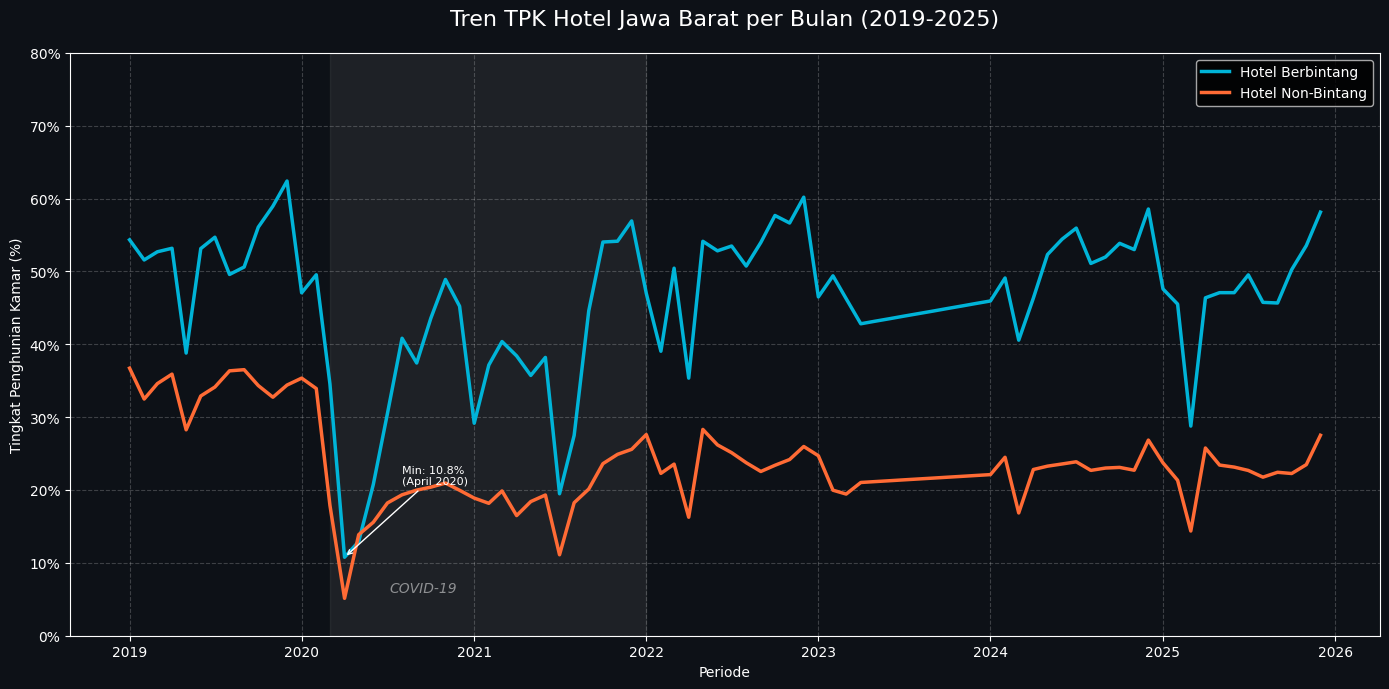

Saved: hotel_viz1_tren_bulanan.png


In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

hotel_filter = hotel[hotel['jenis_hotel'].isin([
    '1. Hotel Berbintang Total',
    '2. Hotel NonBintang Total'
])].sort_values('periode')

label_map = {
    '1. Hotel Berbintang Total': 'Hotel Berbintang',
    '2. Hotel NonBintang Total': 'Hotel Non-Bintang'
}
color_map = {
    '1. Hotel Berbintang Total': PRIMARY_COLOR,
    '2. Hotel NonBintang Total': ACCENT_COLOR
}

for jenis, grp in hotel_filter.groupby('jenis_hotel'):
    ax.plot(grp['periode'], grp['tpk'],
            label=label_map[jenis], color=color_map[jenis],
            linewidth=2.5, zorder=3)

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           color='gray', alpha=0.15, zorder=1)
ax.text(pd.Timestamp('2020-09-15'), 6, 'COVID-19',
        color='white', ha='center', fontsize=10, alpha=0.5, fontstyle='italic')

row_min = (hotel[hotel['jenis_hotel'] == '1. Hotel Berbintang Total']
           .nsmallest(1, 'tpk').iloc[0])
ann_text = 'Min: {:.1f}%\n({} {})'.format(
    row_min['tpk'], row_min['bulan'], int(row_min['tahun']))
ax.annotate(ann_text,
            xy=(row_min['periode'], row_min['tpk']),
            xytext=(row_min['periode'] + pd.DateOffset(months=4), row_min['tpk'] + 10),
            arrowprops=dict(arrowstyle='->', color='white', lw=1),
            color='white', fontsize=8)

ax.set_title('Tren TPK Hotel Jawa Barat per Bulan (2019-2025)', fontsize=16, pad=20)
ax.set_xlabel('Periode')
ax.set_ylabel('Tingkat Penghunian Kamar (%)')
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}hotel_viz1_tren_bulanan.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: hotel_viz1_tren_bulanan.png')

**Interpretasi Viz 1:**
- TPK hotel berbintang secara konsisten lebih tinggi daripada non-bintang di semua periode.
- Pandemi COVID-19 menyebabkan penurunan tajam mulai Maret 2020, dengan titik terendah di April-Mei 2020.
- Tren pemulihan terlihat mulai 2022, namun rata-rata TPK pasca-COVID belum sepenuhnya kembali ke level 2019.

### Viz 2 - Dampak COVID-19: Pra, Saat, dan Pasca

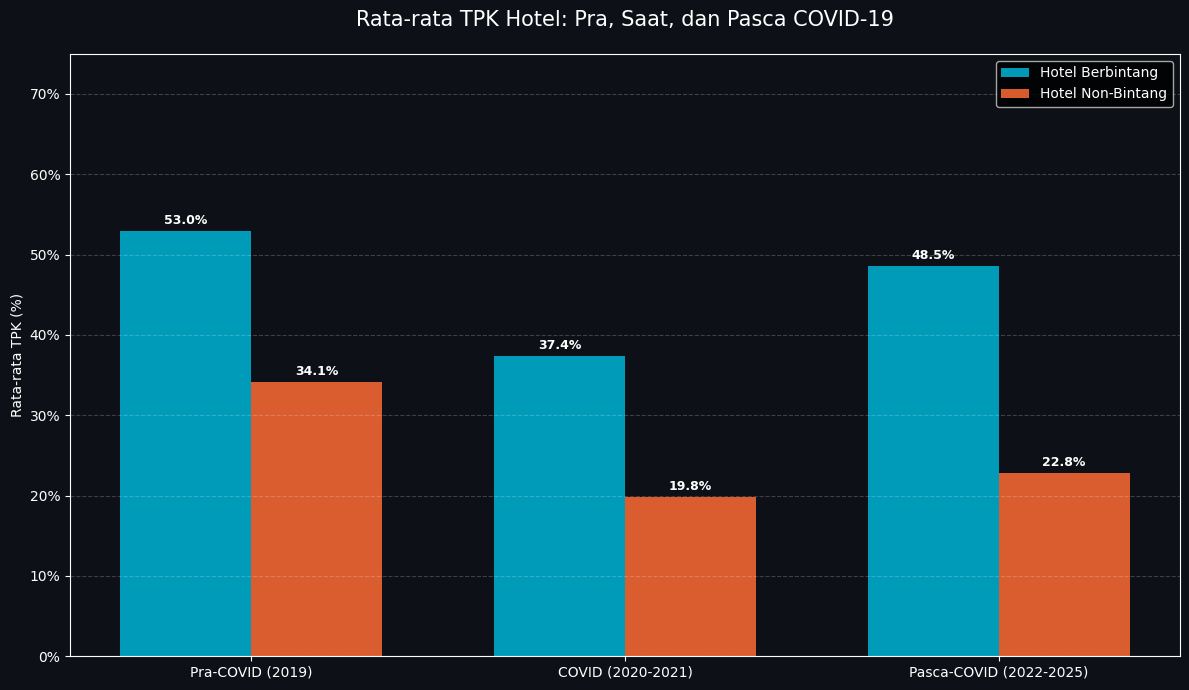

Saved: hotel_viz2_covid_perbandingan.png


In [18]:
def label_period(tahun):
    if tahun == 2019:
        return 'Pra-COVID (2019)'
    elif tahun in [2020, 2021]:
        return 'COVID (2020-2021)'
    else:
        return 'Pasca-COVID (2022-2025)'

hotel_cov = hotel[hotel['jenis_hotel'].isin([
    '1. Hotel Berbintang Total',
    '2. Hotel NonBintang Total'
])].copy()
hotel_cov['period_label'] = hotel_cov['tahun'].apply(label_period)

period_order = ['Pra-COVID (2019)', 'COVID (2020-2021)', 'Pasca-COVID (2022-2025)']
summary_cov = hotel_cov.groupby(['period_label', 'jenis_hotel'])['tpk'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

x = np.arange(len(period_order))
width = 0.35
bar_specs = [
    ('1. Hotel Berbintang Total', PRIMARY_COLOR, 'Hotel Berbintang'),
    ('2. Hotel NonBintang Total', ACCENT_COLOR,  'Hotel Non-Bintang')
]

for i, (jenis, color, label) in enumerate(bar_specs):
    vals = []
    for p in period_order:
        subset = summary_cov[
            (summary_cov['period_label'] == p) &
            (summary_cov['jenis_hotel'] == jenis)
        ]
        vals.append(float(subset['tpk'].values[0]) if len(subset) > 0 else 0.0)
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom',
                color='white', fontsize=9, fontweight='bold')

ax.set_title('Rata-rata TPK Hotel: Pra, Saat, dan Pasca COVID-19', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(period_order)
ax.set_ylabel('Rata-rata TPK (%)')
ax.set_ylim(0, 75)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}hotel_viz2_covid_perbandingan.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: hotel_viz2_covid_perbandingan.png')

**Interpretasi Viz 2:**
- Hotel berbintang mengalami penurunan TPK lebih besar secara absolut karena baseline-nya lebih tinggi.
- Periode pasca-COVID menunjukkan pemulihan, namun rata-rata masih di bawah level 2019 untuk kedua jenis hotel.
- Gap antara hotel berbintang dan non-bintang tetap konsisten di semua periode, menunjukkan segmentasi pasar yang stabil.

### Viz 3 - Pola Musiman TPK (Tahun Normal)

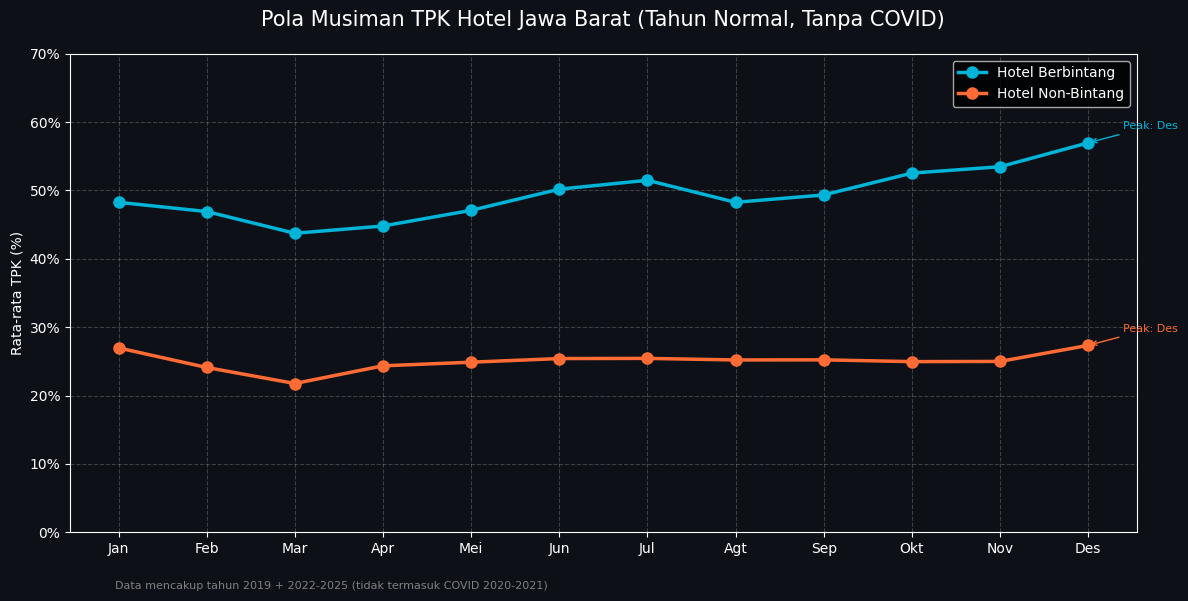

Saved: hotel_viz3_pola_musiman.png


In [19]:
hotel_no_covid = hotel[~hotel['is_covid']]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

seasonal_specs = [
    ('1. Hotel Berbintang Total', PRIMARY_COLOR, 'Hotel Berbintang'),
    ('2. Hotel NonBintang Total', ACCENT_COLOR,  'Hotel Non-Bintang')
]

for jenis, color, label in seasonal_specs:
    seasonal = (hotel_no_covid[hotel_no_covid['jenis_hotel'] == jenis]
                .groupby('bulan_num')['tpk'].mean())
    ax.plot(seasonal.index, seasonal.values, marker='o', linewidth=2.5,
            label=label, color=color, markersize=8)
    peak = int(seasonal.idxmax())
    ax.annotate(
        f'Peak: {BULAN_LABELS[peak - 1]}',
        xy=(peak, seasonal[peak]),
        xytext=(peak + 0.4, float(seasonal[peak]) + 2),
        color=color, fontsize=8,
        arrowprops=dict(arrowstyle='->', color=color, lw=1)
    )

ax.set_title('Pola Musiman TPK Hotel Jawa Barat (Tahun Normal, Tanpa COVID)', fontsize=15, pad=20)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(BULAN_LABELS)
ax.set_ylabel('Rata-rata TPK (%)')
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend()
plt.figtext(0.1, 0.01,
            'Data mencakup tahun 2019 + 2022-2025 (tidak termasuk COVID 2020-2021)',
            color='gray', fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}hotel_viz3_pola_musiman.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: hotel_viz3_pola_musiman.png')

**Interpretasi Viz 3:**
- Terdapat pola musiman yang jelas: TPK mencapai puncak di akhir tahun (November-Desember), sesuai musim liburan.
- TPK terendah terjadi di sekitar bulan Mei, kemungkinan berkaitan dengan periode pasca-lebaran sebelum liburan sekolah.
- Pola musiman hotel berbintang dan non-bintang mengikuti tren serupa dengan magnitude berbeda.

---
## 3. Analisis Lintas Dataset: Wisata Alam x Hotel

Periode overlap: 2019-2022 (hotel mulai 2019, wisata alam sampai 2022).

### Viz 4 - Tren Paralel: Pengunjung Wisata Alam vs TPK Hotel

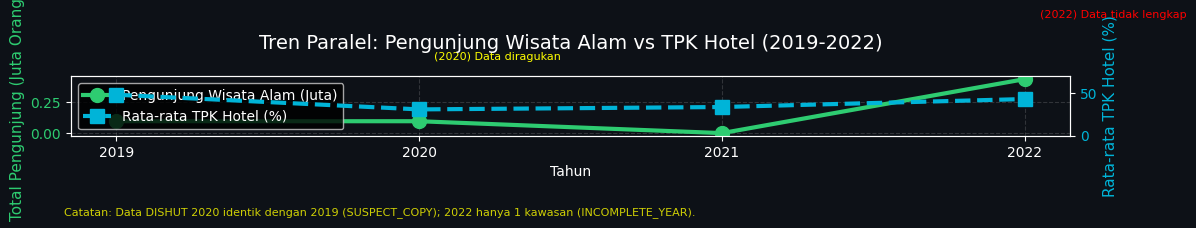

Saved: hotel_viz4_paralel_wisataalam_tpk.png


In [20]:
dishut_yearly = dishut.groupby('tahun').agg(
    total_pengunjung=('jumlah_wisatawan', 'sum'),
    data_flag=('data_flag', lambda x: x.mode()[0])
).reset_index()

hotel_yearly = (hotel[hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total']
                .groupby('tahun')['tpk'].mean()
                .reset_index()
                .rename(columns={'tpk': 'tpk_rata_rata'}))

overlap = (dishut_yearly
           .merge(hotel_yearly, on='tahun')
           .query('2019 <= tahun <= 2022')
           .sort_values('tahun'))

fig, ax1 = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax1.set_facecolor(BG_COLOR)
ax2 = ax1.twinx()
ax2.set_facecolor(BG_COLOR)

ax1.plot(overlap['tahun'], overlap['total_pengunjung'] / 1e6,
         color=GREEN_COLOR, linewidth=3, marker='o', markersize=10,
         label='Pengunjung Wisata Alam (Juta)', zorder=3)
ax2.plot(overlap['tahun'], overlap['tpk_rata_rata'],
         color=PRIMARY_COLOR, linewidth=3, marker='s', markersize=10,
         linestyle='--', label='Rata-rata TPK Hotel (%)', zorder=3)

ax1.set_ylabel('Total Pengunjung (Juta Orang)', color=GREEN_COLOR, fontsize=11)
ax2.set_ylabel('Rata-rata TPK Hotel (%)', color=PRIMARY_COLOR, fontsize=11)
ax1.tick_params(axis='y', labelcolor=GREEN_COLOR)
ax2.tick_params(axis='y', labelcolor=PRIMARY_COLOR)
ax2.set_ylim(0, 70)

FLAG_COLORS = {'SUSPECT_COPY': 'yellow', 'INCOMPLETE_YEAR': 'red'}
FLAG_NOTES  = {'SUSPECT_COPY': 'Data diragukan', 'INCOMPLETE_YEAR': 'Data tidak lengkap'}

for _, row in overlap.iterrows():
    flag = row['data_flag']
    fc = FLAG_COLORS.get(flag)
    if fc:
        yr  = int(row['tahun'])
        pxv = float(row['total_pengunjung']) / 1e6
        ax1.annotate(
            f'({yr}) {FLAG_NOTES[flag]}',
            xy=(yr, pxv),
            xytext=(yr + 0.05, pxv + 0.5),
            color=fc, fontsize=8
        )

lines1, lbls1 = ax1.get_legend_handles_labels()
lines2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbls1 + lbls2, loc='upper left')

ax1.set_title('Tren Paralel: Pengunjung Wisata Alam vs TPK Hotel (2019-2022)', fontsize=14, pad=20)
ax1.set_xlabel('Tahun')
ax1.set_xticks(overlap['tahun'].tolist())
ax1.grid(True, linestyle='--', alpha=0.15)
plt.figtext(0.05, 0.01,
            'Catatan: Data DISHUT 2020 identik dengan 2019 (SUSPECT_COPY); 2022 hanya 1 kawasan (INCOMPLETE_YEAR).',
            color='yellow', fontsize=8, alpha=0.8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}hotel_viz4_paralel_wisataalam_tpk.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: hotel_viz4_paralel_wisataalam_tpk.png')

**Interpretasi Viz 4:**
- Pada tahun 2021 (data DISHUT NORMAL), baik pengunjung wisata alam maupun TPK hotel masih di bawah level pra-COVID 2019.
- Kedua indikator menunjukkan tren searah: turun saat pandemi, mulai pulih setelahnya.
- **Catatan kualitas data:** Data DISHUT 2020 adalah salinan 2019 (tidak dapat digunakan), dan 2022 tidak representatif. Hanya 2 titik data bersih yang tersedia (2019 dan 2021).

### Viz 5 - Scatter: Pengunjung Wisata Alam vs TPK Hotel

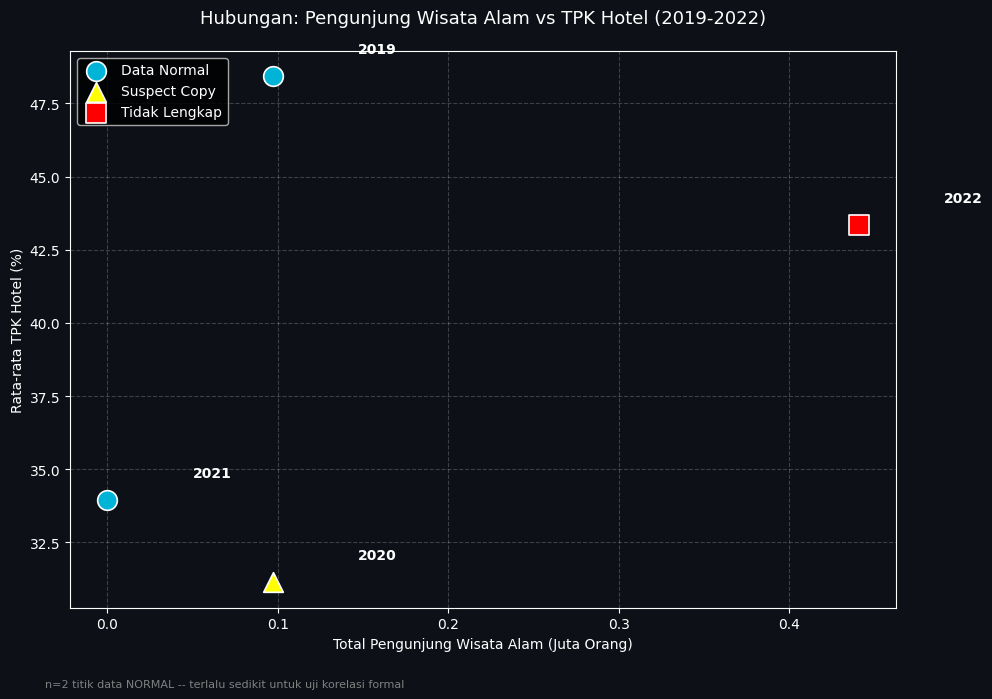

Saved: hotel_viz5_scatter_korelasi.png


In [21]:
dishut_agg = dishut.groupby('tahun').agg(
    total_pengunjung=('jumlah_wisatawan', 'sum'),
    data_flag=('data_flag', lambda x: x.mode()[0])
).reset_index()

hotel_agg = (hotel[hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total']
             .groupby('tahun')['tpk'].mean()
             .reset_index()
             .rename(columns={'tpk': 'tpk_rata'}))

scatter_data = (dishut_agg
                .merge(hotel_agg, on='tahun')
                .query('2019 <= tahun <= 2022'))

MARKER_MAP = {'NORMAL': 'o', 'SUSPECT_COPY': '^', 'INCOMPLETE_YEAR': 's'}
COLOR_FLAG = {'NORMAL': PRIMARY_COLOR, 'SUSPECT_COPY': 'yellow', 'INCOMPLETE_YEAR': 'red'}
LABEL_FLAG = {'NORMAL': 'Data Normal', 'SUSPECT_COPY': 'Suspect Copy', 'INCOMPLETE_YEAR': 'Tidak Lengkap'}

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

plotted_flags = set()
for _, row in scatter_data.iterrows():
    yr   = int(row['tahun'])
    px   = float(row['total_pengunjung']) / 1e6
    py   = float(row['tpk_rata'])
    flag = row['data_flag']
    lbl  = LABEL_FLAG[flag] if flag not in plotted_flags else '_nolegend_'
    ax.scatter(px, py, color=COLOR_FLAG[flag], marker=MARKER_MAP[flag],
               s=200, zorder=4, edgecolors='white', linewidths=1.2, label=lbl)
    ax.annotate(str(yr), xy=(px, py),
                xytext=(px + 0.05, py + 0.8),
                color='white', fontsize=10, fontweight='bold')
    plotted_flags.add(flag)

normal_data = scatter_data[scatter_data['data_flag'] == 'NORMAL']
if len(normal_data) >= 3:
    r_val, _ = stats.pearsonr(normal_data['total_pengunjung'], normal_data['tpk_rata'])
    footnote = f'Pearson r = {r_val:.3f} (n={len(normal_data)}, data NORMAL saja)'
else:
    footnote = f'n={len(normal_data)} titik data NORMAL -- terlalu sedikit untuk uji korelasi formal'

ax.set_title('Hubungan: Pengunjung Wisata Alam vs TPK Hotel (2019-2022)',
             fontsize=13, pad=20)
ax.set_xlabel('Total Pengunjung Wisata Alam (Juta Orang)')
ax.set_ylabel('Rata-rata TPK Hotel (%)')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.2)
plt.figtext(0.05, 0.01, footnote, color='gray', fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}hotel_viz5_scatter_korelasi.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: hotel_viz5_scatter_korelasi.png')

**Interpretasi Viz 5:**
- Scatter menunjukkan posisi relatif tiap tahun: tahun dengan lebih banyak pengunjung cenderung memiliki TPK lebih tinggi.
- Hanya 2 titik data NORMAL yang tersedia -- tidak cukup untuk uji korelasi yang sahih secara statistik.
- Keterbatasan ini akan ditangani pada tahap Model dengan fokus pada data hotel (2019-2025) yang memiliki cakupan lebih panjang.

---
## 4. Ringkasan Temuan Eksploratif

In [22]:
h3 = hotel[hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total']
h3_nc = h3[~h3['is_covid']]

pre  = h3[h3['tahun'] == 2019]['tpk'].mean()
cov  = h3[h3['tahun'].isin([2020, 2021])]['tpk'].mean()
post = h3[h3['tahun'] >= 2022]['tpk'].mean()

peak_m = int(h3_nc.groupby('bulan_num')['tpk'].mean().idxmax())
low_m  = int(h3_nc.groupby('bulan_num')['tpk'].mean().idxmin())

h_bintang    = hotel[hotel['jenis_hotel'] == '1. Hotel Berbintang Total']['tpk'].mean()
h_nonbintang = hotel[hotel['jenis_hotel'] == '2. Hotel NonBintang Total']['tpk'].mean()

print('=' * 60)
print('RINGKASAN TEMUAN EKSPLORATIF')
print('=' * 60)

print(f'\n[1] DAMPAK COVID PADA TPK HOTEL')
print(f'    Pra-COVID  (2019)     : {pre:.1f}%')
print(f'    COVID      (2020-21)  : {cov:.1f}%')
print(f'    Pasca-COVID (2022+)   : {post:.1f}%')
print(f'    Penurunan COVID       : -{pre - cov:.1f} poin ({(pre - cov)/pre*100:.1f}%)')
print(f'    Recovery vs 2019      : {post - pre:+.1f} poin')

print(f'\n[2] POLA MUSIMAN (TAHUN NORMAL)')
print(f'    Bulan puncak TPK     : {BULAN_LABELS[peak_m - 1]} (bulan {peak_m})')
print(f'    Bulan terendah TPK   : {BULAN_LABELS[low_m - 1]} (bulan {low_m})')

print(f'\n[3] GAP JENIS HOTEL')
print(f'    Rata-rata berbintang    : {h_bintang:.1f}%')
print(f'    Rata-rata non-bintang   : {h_nonbintang:.1f}%')
print(f'    Selisih                 : {h_bintang - h_nonbintang:.1f} poin')

print(f'\n[4] LINTAS DATASET (WISATA ALAM x HOTEL)')
print(f'    Overlap                 : 2019-2022 (4 tahun)')
print(f'    Titik data NORMAL       : 2019, 2021 (2 titik bersih)')
print(f'    Pola: saat wisata alam turun (COVID), TPK hotel juga turun')
print(f'    Keterbatasan: n=2 tidak cukup untuk uji statistik formal')
print(f'\n--> Modeling akan difokuskan pada data hotel (2019-2025):')
print(f'    84 bulan, kualitas data baik, cocok untuk time series / forecasting.')

RINGKASAN TEMUAN EKSPLORATIF

[1] DAMPAK COVID PADA TPK HOTEL
    Pra-COVID  (2019)     : 48.4%
    COVID      (2020-21)  : 32.5%
    Pasca-COVID (2022+)   : 39.9%
    Penurunan COVID       : -15.9 poin (32.8%)
    Recovery vs 2019      : -8.5 poin

[2] POLA MUSIMAN (TAHUN NORMAL)
    Bulan puncak TPK     : Des (bulan 12)
    Bulan terendah TPK   : Mar (bulan 3)

[3] GAP JENIS HOTEL
    Rata-rata berbintang    : 46.0%
    Rata-rata non-bintang   : 23.6%
    Selisih                 : 22.4 poin

[4] LINTAS DATASET (WISATA ALAM x HOTEL)
    Overlap                 : 2019-2022 (4 tahun)
    Titik data NORMAL       : 2019, 2021 (2 titik bersih)
    Pola: saat wisata alam turun (COVID), TPK hotel juga turun
    Keterbatasan: n=2 tidak cukup untuk uji statistik formal

--> Modeling akan difokuskan pada data hotel (2019-2025):
    84 bulan, kualitas data baik, cocok untuk time series / forecasting.
